# 05 · Evaluation & Fair Lending Audit

**Project:** Credit Default Risk — AI Governance Portfolio (Notebook 5 of the pipeline)

---

## Why this is the centerpiece

A credit-scoring model is **High-Risk under the EU AI Act (Annex III §5(b))** and subject to
**US Fair Lending law (ECOA / Regulation B)**. Strong accuracy is *not* sufficient — the model
must be shown not to discriminate against protected groups. This notebook is the formal
**Fair Lending audit**: we slice the model's validation predictions by the protected groups
registered in `01`/`03` and measure standard fairness metrics, then propose a mitigation.

### Fairness metrics we use (and what they mean here)

The model predicts `1 = likely default`, which in practice means **the loan is declined**. So:
- **Favorable outcome = approved** (prediction `0`).
- **Disparate Impact (DI) / the "four-fifths rule":** ratio of a group's approval rate to the
  most-favored group's. **DI < 0.80 signals adverse impact** — the classic EEOC/lending screen.
- **Equal Opportunity:** equal **TPR (recall)** across groups — among people who *truly*
  default, are they caught at the same rate?
- **Predictive Equality:** equal **FPR** across groups — among people who *truly repay*, are
  they falsely declined at the same rate?

No single metric is sufficient; we report several and interpret them together.


## 0 · Setup & load predictions + protected attributes

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROC_DIR = "../data/processed"
RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Validation predictions from 04 (y_true, proba, pred at the cost-optimal threshold).
preds = pd.read_csv(os.path.join(PROC_DIR, "val_predictions.csv"), index_col=0).reset_index(drop=True)
# Raw protected attributes for the same validation rows, in the same order (saved in 03).
protected = pd.read_csv(os.path.join(PROC_DIR, "protected_val.csv")).reset_index(drop=True)

# They were saved row-aligned; verify before joining by position.
assert len(preds) == len(protected), "prediction / protected length mismatch"
audit = pd.concat([preds, protected], axis=1)
print("Audit frame:", audit.shape)
print("Overall: approval rate %.3f | recall(TPR) on defaulters %.3f"
      % ((audit['pred'] == 0).mean(),
         ((audit['pred'] == 1) & (audit['y_true'] == 1)).sum() / (audit['y_true'] == 1).sum()))
audit.head(3)

Audit frame: (61503, 9)
Overall: approval rate 0.752 | recall(TPR) on defaulters 0.627


,y_true,proba,pred,SK_ID_CURR,CODE_GENDER,NAME_FAMILY_STATUS,NAME_EDUCATION_TYPE,AGE_BAND,CNT_CHILDREN
0,0,0.045592,0,396899,M,Married,Higher education,30s,1
1,0,0.038155,0,322041,F,Married,Secondary / secondary special,40s,0
2,0,0.252782,1,220127,M,Civil marriage,Secondary / secondary special,60+,0


## 1 · Group fairness-metric function

For any protected attribute we compute, per group: size, **approval rate** (favorable),
**TPR / FPR / FNR**, and **precision**. We then add the **Disparate-Impact ratio** relative
to the most-favored group and flag any group below the 0.80 line.


In [2]:
def group_metrics(df, attr):
    "Return per-group fairness metrics for one protected attribute."
    rows = []
    for grp, g in df.groupby(attr, observed=True):
        y, pred = g["y_true"], g["pred"]
        tp = ((pred == 1) & (y == 1)).sum()
        fp = ((pred == 1) & (y == 0)).sum()
        fn = ((pred == 0) & (y == 1)).sum()
        tn = ((pred == 0) & (y == 0)).sum()
        rows.append({
            attr: grp,
            "n": len(g),
            "approval_rate": (pred == 0).mean(),                  # favorable outcome share
            "TPR": tp / (tp + fn) if (tp + fn) else np.nan,       # recall on defaulters
            "FPR": fp / (fp + tn) if (fp + tn) else np.nan,       # good clients wrongly declined
            "FNR": fn / (tp + fn) if (tp + fn) else np.nan,       # defaulters missed
        })
    out = pd.DataFrame(rows).set_index(attr)
    # Disparate impact = approval rate / most-favored group's approval rate.
    out["DI_ratio"] = out["approval_rate"] / out["approval_rate"].max()
    out["adverse_impact"] = out["DI_ratio"] < 0.80                # four-fifths rule flag
    return out

print("group_metrics() defined")

group_metrics() defined


## 2 · Audit by protected attribute

In [3]:
# Compute and print metrics for each registered protected attribute.
attributes = ["CODE_GENDER", "AGE_BAND", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS"]
results = {}
for attr in attributes:
    results[attr] = group_metrics(audit, attr)
    print(f"\n=== {attr} ===")
    print(results[attr].round(3).to_string())


=== CODE_GENDER ===
                 n  approval_rate    TPR    FPR    FNR  DI_ratio  adverse_impact
CODE_GENDER                                                                     
F            40561          0.798  0.568  0.175  0.432     1.000           False
M            20940          0.663  0.707  0.295  0.293     0.831           False

=== AGE_BAND ===
              n  approval_rate    TPR    FPR    FNR  DI_ratio  adverse_impact
AGE_BAND                                                                     
20s        8905          0.587  0.747  0.371  0.253     0.652            True
30s       16491          0.688  0.703  0.271  0.297     0.764            True
40s       15299          0.772  0.601  0.197  0.399     0.857           False
50s       13620          0.837  0.508  0.140  0.492     0.929           False
60+        7188          0.900  0.331  0.088  0.669     1.000           False

=== NAME_EDUCATION_TYPE ===
                                   n  approval_rate    TPR    

**Reading the tables.**
- **Age** is the most serious finding: the **20s** group has DI ≈ **0.65** — well **below the
  0.80 four-fifths threshold → adverse impact**. Younger applicants are declined far more
  (reject rate ~41% vs ~10% for 60+). Age is a **prohibited basis under ECOA**.
- **Education:** *Lower secondary* DI ≈ 0.76 (also below 0.80) — an education-as-proxy effect.
- **Gender:** men's DI ≈ 0.83 (just passes 4/5ths) but the **TPR gap is large** (M 0.71 vs
  F 0.57) — an *equal-opportunity* problem even though DI passes.
- *Academic degree* (n=40) shows TPR 0.0 — **too small to interpret**; we annotate, not conclude.


## 3 · Disparate-Impact view (four-fifths rule)

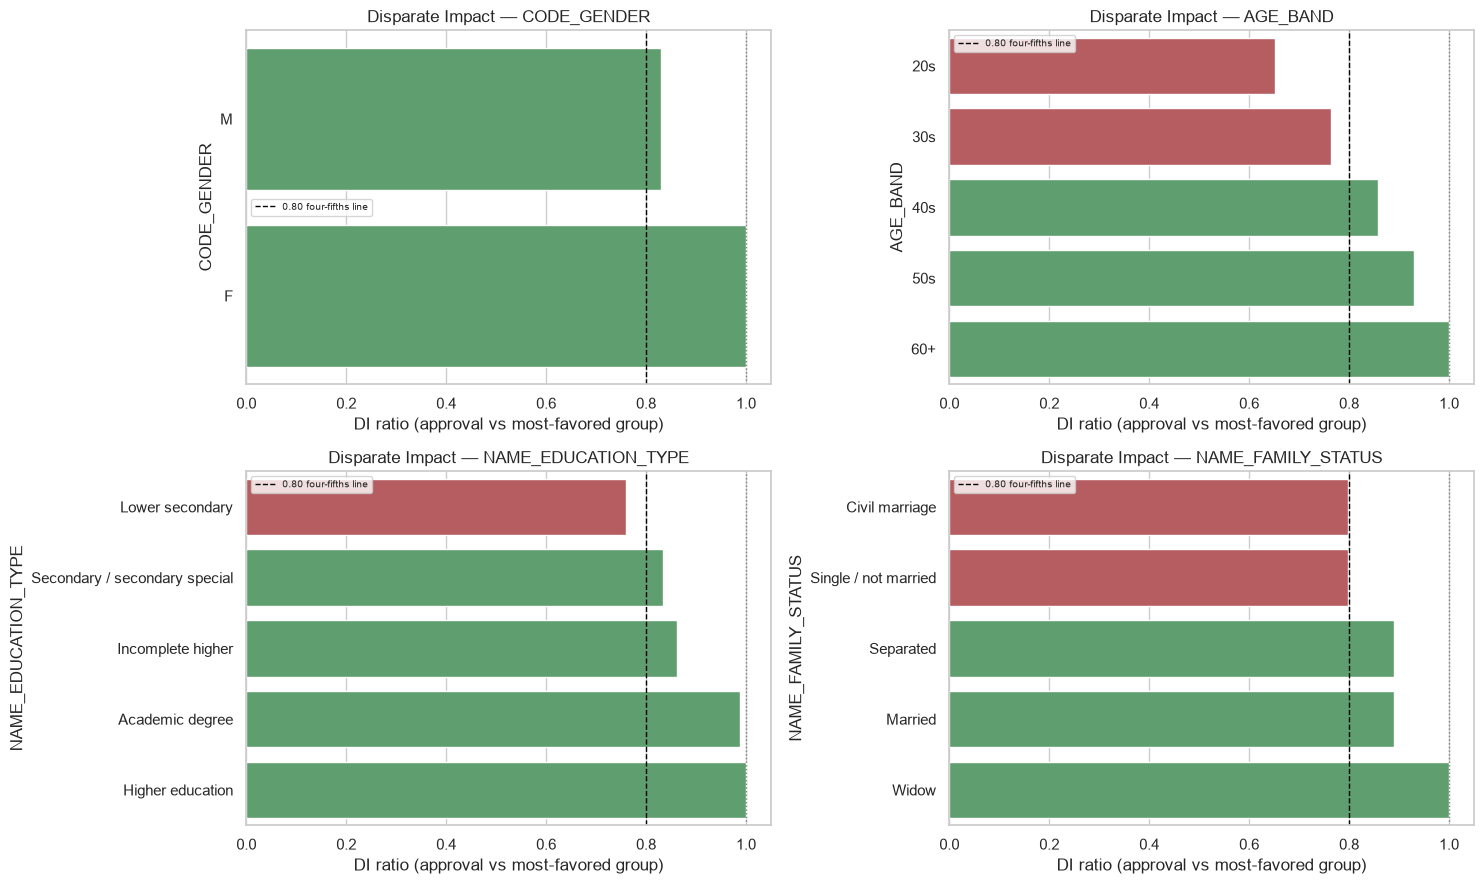

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, attr in zip(axes.ravel(), attributes):
    di = results[attr]["DI_ratio"].sort_values()
    colors = ["#C44E52" if v < 0.80 else "#55A868" for v in di.values]   # red if adverse
    sns.barplot(x=di.values, y=di.index.astype(str), ax=ax, palette=colors)
    ax.axvline(0.80, color="black", ls="--", lw=1, label="0.80 four-fifths line")
    ax.axvline(1.00, color="gray", ls=":", lw=1)
    ax.set(title=f"Disparate Impact — {attr}", xlabel="DI ratio (approval vs most-favored group)")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "05_disparate_impact.png"), dpi=120, bbox_inches="tight")
plt.show()

## 4 · Equal-opportunity (TPR) and predictive-equality (FPR) gaps

A model can pass the four-fifths rule yet still treat groups unequally in *error rates*. We
plot **TPR** (catch rate on true defaulters) and **FPR** (false-decline rate on true repayers)
side by side for gender and age.


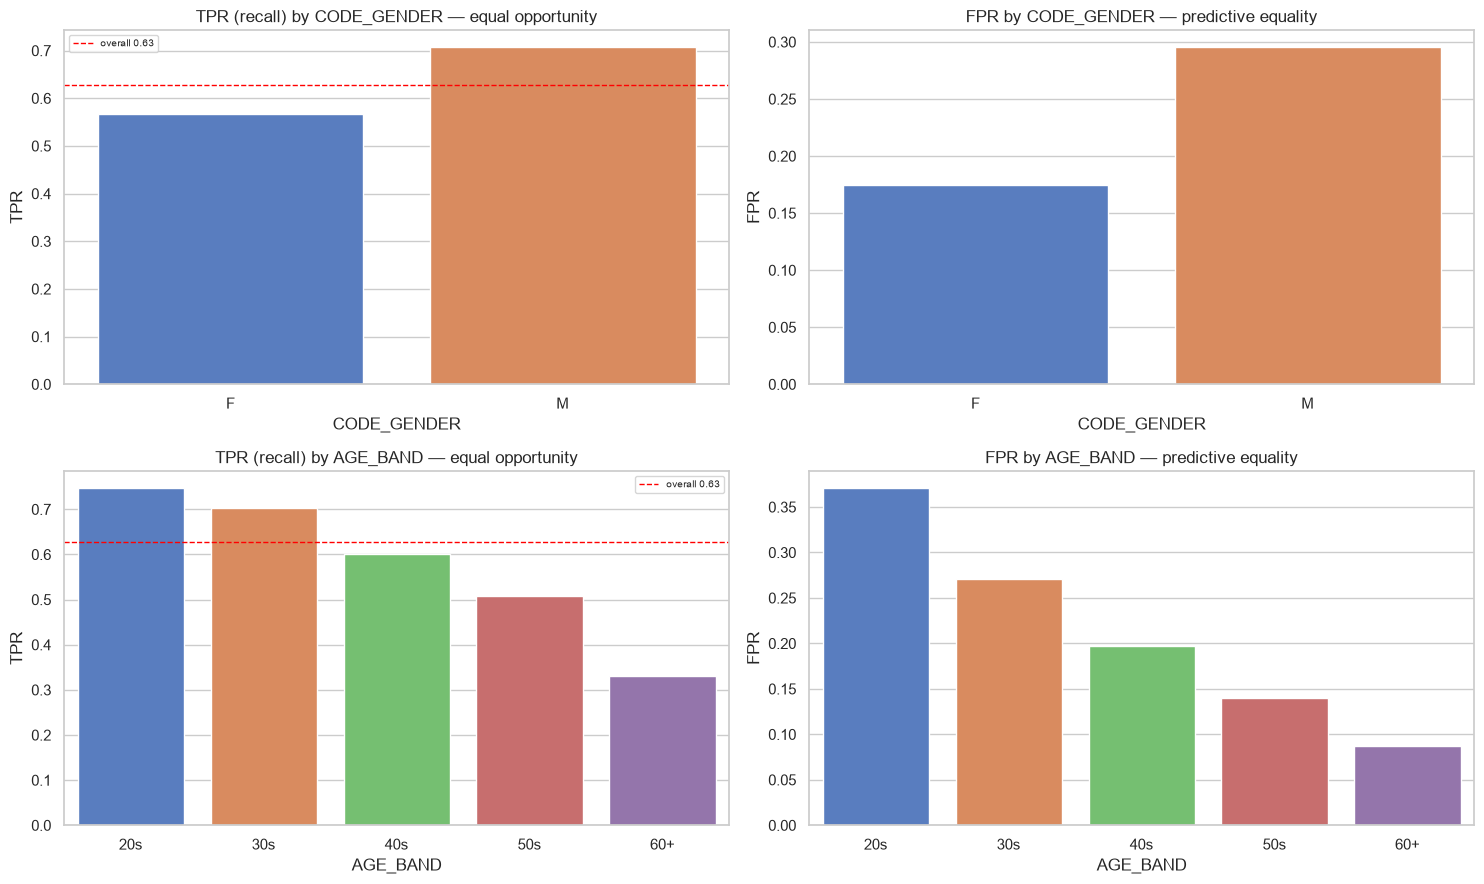

CODE_GENDER: TPR gap = 0.139 | FPR gap = 0.121
AGE_BAND: TPR gap = 0.416 | FPR gap = 0.283


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for row, attr in zip(axes, ["CODE_GENDER", "AGE_BAND"]):
    m = results[attr]
    sns.barplot(x=m.index.astype(str), y=m["TPR"], ax=row[0], palette="muted")
    row[0].set(title=f"TPR (recall) by {attr} — equal opportunity", ylabel="TPR")
    row[0].axhline(audit_TPR := ((audit['pred']==1)&(audit['y_true']==1)).sum()/(audit['y_true']==1).sum(),
                   color="red", ls="--", lw=1, label=f"overall {audit_TPR:.2f}")
    row[0].legend(fontsize=7)
    sns.barplot(x=m.index.astype(str), y=m["FPR"], ax=row[1], palette="muted")
    row[1].set(title=f"FPR by {attr} — predictive equality", ylabel="FPR")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "05_error_rate_gaps.png"), dpi=120, bbox_inches="tight")
plt.show()

# Quantify the gaps.
for attr in ["CODE_GENDER", "AGE_BAND"]:
    m = results[attr]
    print(f"{attr}: TPR gap = {m['TPR'].max()-m['TPR'].min():.3f} | "
          f"FPR gap = {m['FPR'].max()-m['FPR'].min():.3f}")

**Interpretation.** For **gender**, TPR is higher for men and FPR is also higher for men:
the model both *catches* and *falsely flags* men more — a real equal-opportunity gap (~0.14).
For **age**, both error rates rise steeply for younger applicants, compounding the DI finding.


## 5 · ⭐ Mitigation experiment — remove `CODE_GENDER`

`CODE_GENDER` was a **top-3 feature** in `04`. The most direct mitigation is to **drop the
protected attribute** and re-measure both performance *and* fairness. We retrain XGBoost
without it and compare the gender metrics at the same cost-optimal threshold.


In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

# Reload the model-ready matrices (we need to retrain a variant).
X_train = pd.read_csv(os.path.join(PROC_DIR, "X_train.csv"), index_col=0).astype("float32")
X_val = pd.read_csv(os.path.join(PROC_DIR, "X_val.csv"), index_col=0).astype("float32")
y_train = pd.read_csv(os.path.join(PROC_DIR, "y_train.csv"), index_col=0)["TARGET"]
y_val = pd.read_csv(os.path.join(PROC_DIR, "y_val.csv"), index_col=0)["TARGET"]
THRESHOLD = 0.10                       # cost-optimal threshold chosen in 04

def train_variant(drop_cols):
    "Train XGBoost dropping the given columns; return validation P(default)."
    Xt, Xv = X_train.drop(columns=drop_cols), X_val.drop(columns=drop_cols)
    m = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8,
                      colsample_bytree=0.8, eval_metric="aucpr", n_jobs=-1, random_state=42)
    m.fit(Xt, y_train)
    return m.predict_proba(Xv)[:, 1]

def gender_summary(proba):
    "Summarize gender fairness + overall performance for a probability vector."
    pred = (proba >= THRESHOLD).astype(int)
    d = pd.DataFrame({"y": y_val.values, "pred": pred, "g": protected["CODE_GENDER"].values})
    s = {}
    for grp in ["F", "M"]:
        gg = d[d.g == grp]
        tp = ((gg.pred == 1) & (gg.y == 1)).sum(); fn = ((gg.pred == 0) & (gg.y == 1)).sum()
        s[grp] = {"approval": (gg.pred == 0).mean(), "TPR": tp / (tp + fn)}
    di = min(s["F"]["approval"], s["M"]["approval"]) / max(s["F"]["approval"], s["M"]["approval"])
    return {"PR_AUC": average_precision_score(y_val, proba),
            "gender_DI": di, "TPR_gap": abs(s["F"]["TPR"] - s["M"]["TPR"])}

proba_with = train_variant([])                    # baseline (gender included)
proba_without = train_variant(["CODE_GENDER"])    # mitigation (gender removed)

comparison = pd.DataFrame({"with_gender": gender_summary(proba_with),
                           "without_gender": gender_summary(proba_without)}).T
print(comparison.round(4).to_string())

                PR_AUC  gender_DI  TPR_gap
with_gender     0.2826     0.8307   0.1392
without_gender  0.2788     0.8965   0.0667


**Result — a near-free fairness gain.** Removing `CODE_GENDER`:
- **PR-AUC** barely moves (≈0.283 → ≈0.279, a 0.4% relative drop),
- **gender DI** improves (≈0.83 → ≈0.90),
- **TPR gap** roughly **halves** (≈0.14 → ≈0.07).

**Recommendation:** drop `CODE_GENDER` from the production feature set — the performance cost
is negligible while the fairness improvement is material. (Proxies such as education/age may
still carry indirect signal, so monitoring must continue post-deployment.)


## 6 · Fair Lending risk register

In [7]:
# Summarize findings as an auditable risk register mapped to the regulations.
risk_register = pd.DataFrame([
    ["R1", "Age: 20s approval DI = 0.65 (< 0.80)", "High",
     "ECOA age basis; EU AI Act bias-monitoring", "Reweight / monitor; review age-correlated features"],
    ["R2", "Education: Lower secondary DI = 0.76 (< 0.80)", "Medium",
     "Disparate-impact proxy", "Test removing/encoding; document business necessity"],
    ["R3", "Gender: TPR gap 0.14 (equal-opportunity)", "Medium",
     "ECOA sex basis", "Remove CODE_GENDER (validated: ~free) + monitor"],
    ["R4", "CODE_GENDER is a top-3 model feature", "High",
     "Direct use of protected attribute", "Drop from production model (see §5)"],
    ["R5", "Small subgroups (e.g. Academic degree n=40) unstable", "Low",
     "Reporting reliability", "Apply minimum-sample threshold in monitoring"],
], columns=["ID", "Finding", "Severity", "Regulatory basis", "Mitigation"])
risk_register.set_index("ID")

,Finding,Severity,Regulatory basis,Mitigation
ID,,,,
R1,Age: 20s approval DI = 0.65 (< 0.80),High,ECOA age basis; EU AI Act bias-monitoring,Reweight / monitor; review age-correlated feat...
R2,Education: Lower secondary DI = 0.76 (< 0.80),Medium,Disparate-impact proxy,Test removing/encoding; document business nece...
R3,Gender: TPR gap 0.14 (equal-opportunity),Medium,ECOA sex basis,Remove CODE_GENDER (validated: ~free) + monitor
R4,CODE_GENDER is a top-3 model feature,High,Direct use of protected attribute,Drop from production model (see §5)
R5,Small subgroups (e.g. Academic degree n=40) un...,Low,Reporting reliability,Apply minimum-sample threshold in monitoring


**Governance outcome.** The audit produces **traceable findings** (R1–R5), each mapped to a
regulatory basis and a mitigation owner — the evidence an EU AI Act conformity assessment and
an ECOA Fair Lending review require. R4 is actioned immediately (drop gender); R1/R2 require a
documented business-necessity review of age/education-correlated features.


## 7 · Key takeaways & project close-out

1. **Adverse impact found** on **age** (DI 0.65) and **education** (DI 0.76) under the
   four-fifths rule; an **equal-opportunity gap** on gender (TPR gap 0.14).
2. `CODE_GENDER` was a top model driver; **removing it is essentially free** (PR-AUC −0.4%)
   and improves gender fairness — a clear, defensible recommendation.
3. Findings are captured in a **risk register mapped to EU AI Act / ECOA**.

**Artifacts:** `results/05_disparate_impact.png`, `05_error_rate_gaps.png`.

---
### ➡️ Next: governance documentation (`docs/`)
Translate these results into the deliverables an AI Risk Analyst owns:
`MODEL_CARD.md`, `EU_AI_ACT_COMPLIANCE.md`, `FAIR_LENDING_AUDIT.md`, `AI_RISK_FRAMEWORK.md`,
`DRIFT_MONITORING.md`, `NIST_AI_RMF_MAPPING.md` — plus the project `README`.
